In [1]:
import drjit as dr
import cupy as xp
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch as th 
from drjit.cuda.ad import Array2f, Array1f, ArrayXf, Float, TensorXf

device = th.device("cuda:0" if th.cuda.is_available() else "cpu")

In [2]:
import sys
sys.path.append("src")
import xrt_toolkit as xtk

### 3D volume (5, 5, 5) and geometry

In [3]:
size = 5
detector_count = 250
x = xp.zeros((size, size, size), dtype=xp.float32)
x[2, 2, 2] = 1.0

angles = xp.linspace(0, xp.pi, 10, dtype=xp.float32, endpoint=False)
detector_spec = xtk.DetectorSpec((5,5), (detector_count, detector_count))
ray_spec = xtk.parallel_beam(Float(angles), detector_spec)

knot_spec = xtk.UniformSpec(start=(-(size//2), -(size//2), -(size//2)), step=(1,1,1), num=(size, size, size))

In [4]:
order = 0
x_dr = Float(x.reshape(-1))
y_dr = xtk.xrt_struct_apply(ray_spec, knot_spec, order, x_dr)


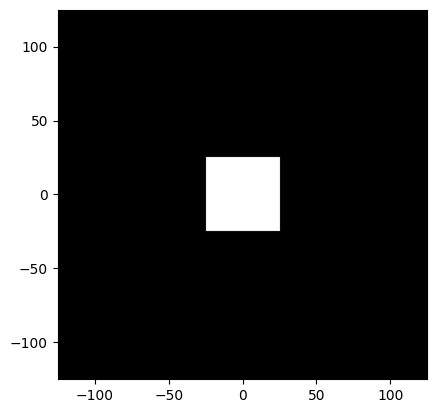

In [5]:
plt.imshow(np.asarray(y_dr).reshape(len(angles), detector_count, detector_count)[0], cmap='gray', extent=[-detector_count/2, detector_count/2, -detector_count/2, detector_count/2])

In [1]:
import drjit as dr
import drjit.nn as nn
# pick a backend+dtype. CUDA example (use llvm.ad for CPU):
from drjit.cuda.ad import TensorXf  

net = nn.Sequential(
    nn.Linear(-1, 16), nn.ReLU(),
    nn.Linear(16, 16), nn.ReLU(),
    nn.Linear(16, 16), nn.ReLU(),
    nn.Linear(16, 16), nn.ReLU(),
    nn.Linear(16, 1)
)

# allocate parameter storage and pack into a training-optimal layout
net = net.alloc(TensorXf, size=4)          # input CoopVec has length 4
coeffs, net = nn.pack(net, layout='training')


jitc_llvm_init(): LLVM API initialization failed ..


: 